In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [10]:
folder = Path(".")   # same folder as the notebook

def load_file(path):
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
    else:
        df = pd.read_excel(path)

    rename = {}
    for col in df.columns:
        c = col.strip().lower()
        if c in ["stock", "ticker", "stock_name", "symbol"]:
            rename[col] = "stock"
        elif c in [
            "avg_price_improvement",
            "average_price_improvement",
            "avg_improvement_per_trade",
            "average_improvement",
            "price_improvement",
            "improvement"
        ]:
            rename[col] = "improvement"

    df = df.rename(columns=rename)
    return df[["stock", "improvement"]].copy()

def get_strategy_name(filename):
    name = filename.lower()
    if "oracle" in name:
        return "Oracle"
    elif "strategy1" in name:
        return "Strategy 1"
    elif "strategy2" in name or "leadlag" in name:
        return "Strategy 2"
    elif "strategy3" in name:
        return "Strategy 3"
    elif "strategy4" in name:
        return "Strategy 4"
    elif "strategy5" in name:
        return "Strategy 5"
    else:
        return filename

buy_frames = []
sell_frames = []

for path in folder.iterdir():
    if path.suffix.lower() not in [".csv", ".xlsx", ".xls"]:
        continue

    name = path.name.lower()
    if "oracle" in name:
        continue
    strategy = get_strategy_name(path.name)

    if "buy" in name:
        df = load_file(path)
        df["strategy"] = strategy
        buy_frames.append(df)

    elif "sell" in name:
        df = load_file(path)
        df["strategy"] = strategy
        sell_frames.append(df)

buy_df = pd.concat(buy_frames, ignore_index=True)
sell_df = pd.concat(sell_frames, ignore_index=True)

buy_pivot = buy_df.pivot(index="stock", columns="strategy", values="improvement")
sell_pivot = sell_df.pivot(index="stock", columns="strategy", values="improvement")

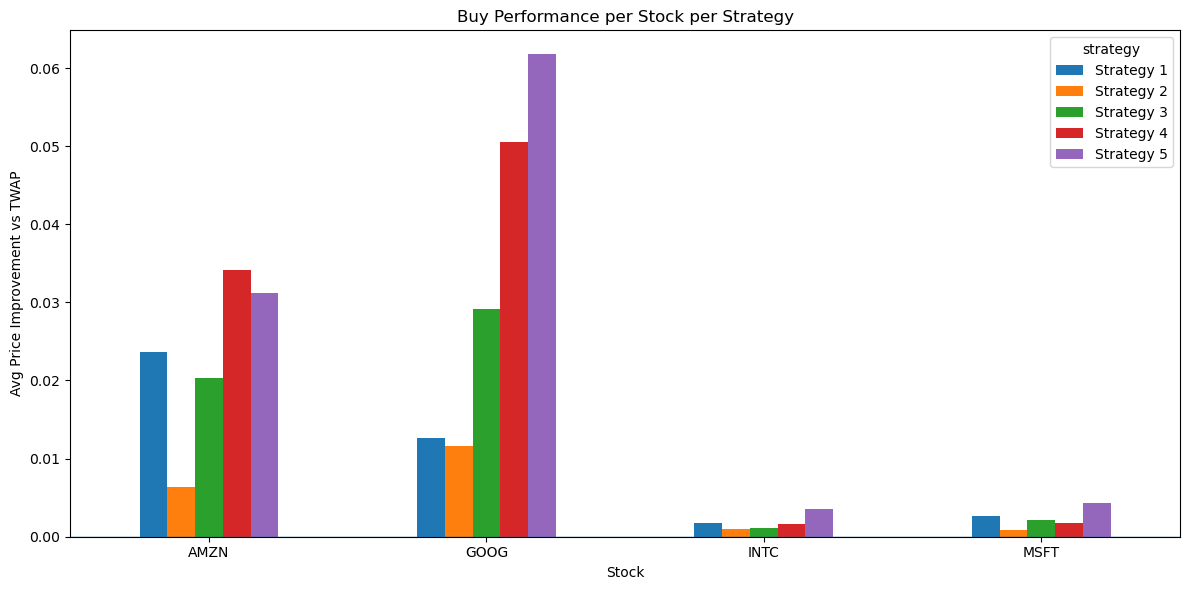

In [11]:
buy_pivot.plot(kind="bar", figsize=(12, 6))
plt.axhline(0, linewidth=1)
plt.title("Buy Performance per Stock per Strategy")
plt.xlabel("Stock")
plt.ylabel("Avg Price Improvement vs TWAP")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

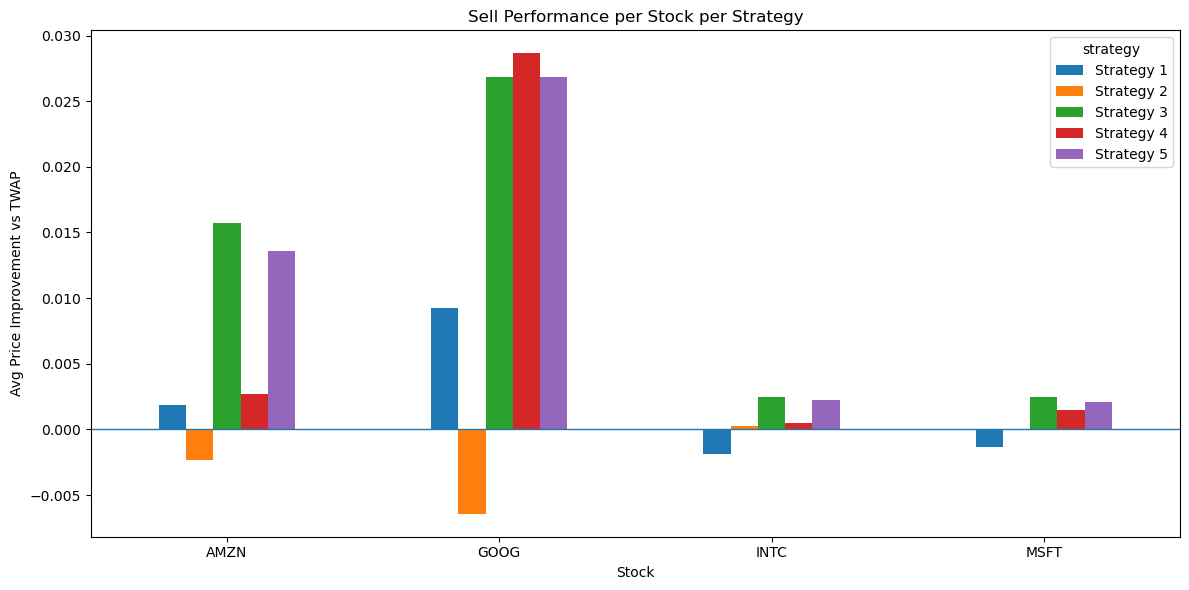

In [12]:
sell_pivot.plot(kind="bar", figsize=(12, 6))
plt.axhline(0, linewidth=1)
plt.title("Sell Performance per Stock per Strategy")
plt.xlabel("Stock")
plt.ylabel("Avg Price Improvement vs TWAP")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
buy_df.head()

,stock,improvement,strategy
0,AMZN,0.034198,Strategy 4
1,GOOG,0.050494,Strategy 4
2,INTC,0.001605,Strategy 4
3,MSFT,0.001728,Strategy 4
4,AMZN,0.020296,Strategy 3


In [14]:
# Find the best 3 strategies overall
buy_df.groupby("strategy")["improvement"].mean().sort_values(ascending=False).head(5)

strategy
Strategy 5    0.025215
Strategy 4    0.022006
Strategy 3    0.013157
Strategy 1    0.010171
Strategy 2    0.004969
Name: improvement, dtype: float64

In [15]:
# Find the best 3 strategies overall
sell_df.groupby("strategy")["improvement"].mean().sort_values(ascending=False).head(5)

strategy
Strategy 3    0.011889
Strategy 5    0.011173
Strategy 4    0.008333
Strategy 1    0.001981
Strategy 2   -0.002130
Name: improvement, dtype: float64

In [16]:
(buy_df.groupby("strategy")["improvement"].mean() + sell_df.groupby("strategy")["improvement"].mean()).sort_values(ascending=False).head(5)

strategy
Strategy 5    0.036388
Strategy 4    0.030340
Strategy 3    0.025046
Strategy 1    0.012152
Strategy 2    0.002840
Name: improvement, dtype: float64